# AI Based Fake News Detection Tool

## Module 4 — Model Training

### CodeVedX AI/ML Internship — Project 3

---

## 📌 Project Overview

This notebook builds the **complete NLP machine-learning pipeline** for
the Fake News Detection project. It uses the cleaned articles from
Module 2 (`data/processed/fake_news_dataset.csv`) and trains multiple
classifiers to distinguish **Fake (0)** from **True (1)** news.

## 🎯 Purpose of Model Training

- Convert raw article text into numeric features using **TF-IDF**.
- Train four classifiers: **Logistic Regression**, **Multinomial
  Naive Bayes**, **Linear SVM**, and **Random Forest**.
- Evaluate every model with a consistent, professional metric suite.
- Compare performance, select the **best model**, and persist it.
- Generate a model report and evaluation charts for stakeholders.

## 🔄 Pipeline Overview

```text
clean_text (CSV)  ->  Train/Test Split (80/20, stratified)
        |
        v
   TF-IDF Vectorizer (fit on TRAIN only)
        |
        v
   Train 4 Models (LogReg, NB, LinearSVM, RandomForest)
        |
        v
   Evaluate (accuracy, precision, recall, F1, ROC-AUC, CM)
        |
        v
   Compare -> Select Best (highest F1, tie-break accuracy)
        |
        v
   Save Model + Vectorizer (joblib)
        |
        v
   Validate (reload + predict on sample articles)
```

## 📤 Expected Outputs

- `models/fake_news_model.pkl` — the selected best model.
- `models/tfidf_vectorizer.pkl` — the fitted TF-IDF vectorizer.
- `outputs/reports/model_report.txt` — full model report.
- Evaluation charts in `outputs/charts/` (comparison, confusion
  matrices, ROC, precision-recall, top features).


## Step 2 — Import Libraries

### Why this step is required

A consistent set of libraries is needed for data manipulation
(`pandas`, `numpy`), plotting (`matplotlib`, `seaborn`), filesystem-safe
paths (`pathlib`), suppressing non-critical warnings (`warnings`), model
persistence (`joblib`), and machine learning (`scikit-learn`).

### What it does

Imports all libraries used throughout the notebook and prints their
versions.

### Expected output

A confirmation message listing the Python version and all imported
libraries.


In [1]:
# ================================================
# STEP 2: Import Libraries
# ================================================

import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# scikit-learn components
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')

# Professional style configuration
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.autolayout': True,
})

print(f'Python      : {sys.version.split()[0]}')
print(f'Pandas      : {pd.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'Matplotlib  : {plt.matplotlib.__version__}')
print(f'Seaborn     : {sns.__version__}')
print(f'Scikit-learn: {__import__("sklearn").__version__}')
print(f'Joblib      : {joblib.__version__}')
print('\nAll libraries imported successfully.')


Python      : 3.14.0
Pandas      : 2.3.3
NumPy       : 2.3.3
Matplotlib  : 3.10.7
Seaborn     : 0.13.2
Scikit-learn: 1.7.2
Joblib      : 1.5.2

All libraries imported successfully.


In [2]:
# ================================================
# STEP 3 (setup): Paths & Output Directories
# ================================================

# Project-relative paths (notebooks/ -> project root)
PROJECT_ROOT = Path('..').resolve()
PROCESSED_CSV = PROJECT_ROOT / 'data' / 'processed' / 'fake_news_dataset.csv'
MODELS_DIR = PROJECT_ROOT / 'models'
CHARTS_DIR = PROJECT_ROOT / 'outputs' / 'charts'
REPORTS_DIR = PROJECT_ROOT / 'outputs' / 'reports'
MODEL_PATH = MODELS_DIR / 'fake_news_model.pkl'
VECTORIZER_PATH = MODELS_DIR / 'tfidf_vectorizer.pkl'
MODEL_REPORT = REPORTS_DIR / 'model_report.txt'

# Ensure output directories exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root   : {PROJECT_ROOT}')
print(f'Dataset        : {PROCESSED_CSV}')
print(f'Models dir     : {MODELS_DIR}')
print(f'Charts dir     : {CHARTS_DIR}')
print(f'Report dir     : {REPORTS_DIR}')


Project root   : D:\New Project\CodeVedex Projects\CODEVEDX\Project-03-Fake-News-Detection
Dataset        : D:\New Project\CodeVedex Projects\CODEVEDX\Project-03-Fake-News-Detection\data\processed\fake_news_dataset.csv
Models dir     : D:\New Project\CodeVedex Projects\CODEVEDX\Project-03-Fake-News-Detection\models
Charts dir     : D:\New Project\CodeVedex Projects\CODEVEDX\Project-03-Fake-News-Detection\outputs\charts
Report dir     : D:\New Project\CodeVedex Projects\CODEVEDX\Project-03-Fake-News-Detection\outputs\reports


## Step 3 — Load Dataset

### Why this step is required

We must load the processed dataset and verify its integrity before
training. Confirming the shape, columns, label distribution, and the
absence of missing values in `clean_text` / `label` prevents silent
failures downstream.

### What it does

Loads `data/processed/fake_news_dataset.csv` and displays the shape,
columns, label counts/percentages, and missing-value checks.

### Expected output

A summary confirming a clean, balanced, model-ready dataset.


In [3]:
# ================================================
# STEP 3: Load Dataset
# ================================================

try:
    df = pd.read_csv(PROCESSED_CSV, encoding='utf-8')
    print('Dataset loaded successfully.')
except FileNotFoundError as exc:
    raise SystemExit(f'Dataset not found: {PROCESSED_CSV}') from exc
except pd.errors.EmptyDataError as exc:
    raise SystemExit(f'Dataset is empty: {PROCESSED_CSV}') from exc

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')

# --- Label distribution ---
label_counts = df['label'].value_counts().sort_index()
label_pct = df['label'].value_counts(normalize=True).sort_index() * 100
label_df = pd.DataFrame({'Count': label_counts, 'Percentage': label_pct.round(2)})
label_df.index = ['Fake (0)', 'True (1)']
label_df.index.name = 'Label'
print('\nLabel distribution:')
display(label_df)

# --- Missing-value checks ---
missing_clean = int(df['clean_text'].isna().sum())
missing_label = int(df['label'].isna().sum())
print('\n--- Missing-value verification ---')
print(f'  Missing clean_text : {missing_clean:,}')
print(f'  Missing label      : {missing_label:,}')

assert missing_clean == 0, 'clean_text contains missing values!'
assert missing_label == 0, 'label contains missing values!'
print('\n✅ No missing clean_text or label — dataset is model-ready.')


Dataset loaded successfully.
Shape: 43,971 rows x 10 columns

Columns: ['title', 'text', 'subject', 'date', 'label', 'clean_text', 'word_count', 'char_count', 'sentence_count', 'avg_word_length']

Label distribution:


,Count,Percentage
Label,,
Fake (0),22761,51.76
True (1),21210,48.24



--- Missing-value verification ---
  Missing clean_text : 0
  Missing label      : 0

✅ No missing clean_text or label — dataset is model-ready.


## Step 4 — Prepare Features

### Why this step is required

Scikit-learn estimators expect a feature matrix `X` and a target vector
`y`. For this NLP task the raw feature is the cleaned article text; the
target is the binary `label`.

### What it does

Creates `X = df['clean_text']` and `y = df['label']`, then prints the
class names for clarity.

### Expected output

Two arrays (texts and labels) plus the class names `['Fake', 'True']`.


In [4]:
# ================================================
# STEP 4: Prepare Features
# ================================================

# Feature matrix: cleaned article text
X = df['clean_text']

# Target vector: binary label (0 = Fake, 1 = True)
y = df['label']

CLASS_NAMES = ['Fake', 'True']

print(f'X (features)   : {len(X):,} articles (clean_text)')
print(f'y (target)     : {len(y):,} labels (Fake=0, True=1)')
print(f'Class names    : {CLASS_NAMES}')


X (features)   : 43,971 articles (clean_text)
y (target)     : 43,971 labels (Fake=0, True=1)
Class names    : ['Fake', 'True']


## Step 5 — Train/Test Split

### Why this step is required

We must hold out a portion of the data to obtain an unbiased estimate of
generalisation. A **stratified** split preserves the class proportions in
both train and test sets, which is important for reliable metrics.

### What it does

Splits `X` and `y` into 80% train / 20% test with `random_state=42` and
`stratify=y`.

### Expected output

The train/test shapes and the class distribution in each split.


In [5]:
# ================================================
# STEP 5: Train/Test Split
# ================================================

# 80% train / 20% test, stratified by label, fixed random state
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {len(X_train):,} articles')
print(f'Test size  : {len(X_test):,} articles')

# Verify stratification
train_dist = y_train.value_counts(normalize=True).sort_index().round(4)
test_dist = y_test.value_counts(normalize=True).sort_index().round(4)
print('\nClass distribution — Train:')
print(train_dist.to_string())
print('\nClass distribution — Test:')
print(test_dist.to_string())


Train size : 35,176 articles
Test size  : 8,795 articles

Class distribution — Train:
label
0    0.5176
1    0.4824

Class distribution — Test:
label
0    0.5177
1    0.4823


## Step 6 — TF-IDF Vectorization

### Why this step is required

Machine-learning models cannot consume raw text. **TF-IDF** (Term
Frequency — Inverse Document Frequency) converts each article into a
sparse numeric vector that weights words by how informative they are:
words frequent in one document but rare in the corpus get higher scores.

### What it does

- Builds a `TfidfVectorizer` with `max_features=20000`, `ngram_range=(1,2)`,
  `min_df=2`, `max_df=0.95`, `sublinear_tf=True`, `stop_words='english'`.
- **Fits on the training data only** (critical to avoid data leakage).
- Transforms both train and test sets.
- Reports the vocabulary size and the resulting feature-matrix shapes.

### Expected output

A fitted vectorizer, sparse train/test matrices, vocabulary size, and
feature-matrix shapes.


In [6]:
# ================================================
# STEP 6: TF-IDF Vectorization
# ================================================

# Configuration from the task specification
VECTORIZER_CONFIG = {
    'max_features': 20000,
    'ngram_range': (1, 2),
    'min_df': 2,
    'max_df': 0.95,
    'sublinear_tf': True,
    'stop_words': 'english',
}

vectorizer = TfidfVectorizer(**VECTORIZER_CONFIG)

# Fit ONLY on the training data (no data leakage)
print('Fitting TF-IDF vectorizer on TRAINING data only...')
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the test data with the fitted vectorizer
X_test_tfidf = vectorizer.transform(X_test)

vocab_size = len(vectorizer.vocabulary_)
print(f'\nVocabulary size            : {vocab_size:,}')
print(f'Feature matrix (train)     : {X_train_tfidf.shape[0]:,} x {X_train_tfidf.shape[1]:,}')
print(f'Feature matrix (test)      : {X_test_tfidf.shape[0]:,} x {X_test_tfidf.shape[1]:,}')

# Sparsity check
sparsity = 1.0 - (X_train_tfidf.nnz / np.prod(X_train_tfidf.shape))
print(f'Train matrix sparsity      : {sparsity:.4%}')


Fitting TF-IDF vectorizer on TRAINING data only...



Vocabulary size            : 20,000
Feature matrix (train)     : 35,176 x 20,000
Feature matrix (test)      : 8,795 x 20,000
Train matrix sparsity      : 99.1756%


## Step 7 — Train Multiple Models

### Why this step is required

Different algorithms make different assumptions about the data. Training
a diverse set of classifiers lets us compare them empirically and pick
the one that generalises best to unseen news articles.

### What it does

Trains four models on the TF-IDF training matrix and records training
time for each:

| # | Model                    | Notes                                  |
|---|--------------------------|----------------------------------------|
| 1 | Logistic Regression      | Strong linear baseline                 |
| 2 | Multinomial Naive Bayes  | Probabilistic, ideal for word counts   |
| 3 | Linear SVM               | Max-margin linear classifier           |
| 4 | Random Forest (optional) | Non-linear ensemble of decision trees  |

A fixed `random_state=42` guarantees reproducibility.

### Expected output

Four fitted classifiers with their training times.


In [7]:
# ================================================
# STEP 7: Train Multiple Models
# ================================================

# Dictionary of models to train (fixed seeds for reproducibility)
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=42, n_jobs=-1
    ),
    'Multinomial Naive Bayes': MultinomialNB(alpha=1.0),
    'Linear SVM': LinearSVC(
        max_iter=5000, random_state=42, loss='hinge'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
}

trained_models: dict[str, object] = {}
train_times: dict[str, float] = {}

print('Training models...')
print('=' * 60)
for name, model in MODELS.items():
    start = time.perf_counter()
    model.fit(X_train_tfidf, y_train)
    elapsed = time.perf_counter() - start
    trained_models[name] = model
    train_times[name] = elapsed
    print(f'  {name:<26} trained in {elapsed:.2f}s')

print('\n✅ All models trained.')


Training models...


  Logistic Regression        trained in 4.51s
  Multinomial Naive Bayes    trained in 0.06s


  Linear SVM                 trained in 1.81s


  Random Forest              trained in 17.45s

✅ All models trained.


## Step 8 — Evaluate Every Model

### Why this step is required

Raw training is meaningless without rigorous evaluation. A consistent
metric suite (accuracy, precision, recall, F1, ROC-AUC), a detailed
classification report, and a confusion matrix reveal both the overall
quality and the specific error patterns of each model.

### What it does

For every model it computes predictions, timing, classification report,
confusion matrix, and ROC-AUC (using `predict_proba` where available,
or `decision_function` for Linear SVM).

### Expected output

A structured results dictionary holding all metrics for every model.


In [8]:
# ================================================
# STEP 8: Evaluate Every Model
# ================================================

def decision_scores(model, X):
    """Return decision scores for a fitted model."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X)
    return model.predict(X)


results: dict[str, dict] = {}
prediction_times: dict[str, float] = {}

for name, model in trained_models.items():
    print('=' * 70)
    print(f'EVALUATING: {name}')
    print('=' * 70)

    # --- Prediction timing ---
    start = time.perf_counter()
    y_pred = model.predict(X_test_tfidf)
    pred_time = time.perf_counter() - start
    prediction_times[name] = pred_time

    # --- Core metrics ---
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # --- ROC-AUC ---
    scores = decision_scores(model, X_test_tfidf)
    try:
        roc_auc = roc_auc_score(y_test, scores)
    except ValueError:
        roc_auc = float('nan')

    print(f'  Accuracy    : {accuracy:.4f}')
    print(f'  Precision   : {precision:.4f}')
    print(f'  Recall      : {recall:.4f}')
    print(f'  F1 Score    : {f1:.4f}')
    print(f'  ROC-AUC     : {roc_auc:.4f}')
    print(f'  Train time  : {train_times[name]:.2f}s')
    print(f'  Predict time: {pred_time:.4f}s')

    print('\n  --- Classification Report ---')
    report = classification_report(y_test, y_pred, target_names=CLASS_NAMES)
    print(report)

    print('  --- Confusion Matrix ---')
    print(f'    TN={cm[0, 0]:,}  FP={cm[0, 1]:,}')
    print(f'    FN={cm[1, 0]:,}  TP={cm[1, 1]:,}')

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'scores': scores,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'train_time': train_times[name],
        'prediction_time': pred_time,
        'classification_report': report,
    }


EVALUATING: Logistic Regression
  Accuracy    : 0.9916
  Precision   : 0.9890
  Recall      : 0.9936
  F1 Score    : 0.9913
  ROC-AUC     : 0.9994
  Train time  : 4.51s
  Predict time: 0.0037s

  --- Classification Report ---
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4553
        True       0.99      0.99      0.99      4242

    accuracy                           0.99      8795
   macro avg       0.99      0.99      0.99      8795
weighted avg       0.99      0.99      0.99      8795

  --- Confusion Matrix ---
    TN=4,506  FP=47
    FN=27  TP=4,215
EVALUATING: Multinomial Naive Bayes
  Accuracy    : 0.9553
  Precision   : 0.9506
  Recall      : 0.9571
  F1 Score    : 0.9538
  ROC-AUC     : 0.9898
  Train time  : 0.06s
  Predict time: 0.0094s

  --- Classification Report ---
              precision    recall  f1-score   support

        Fake       0.96      0.95      0.96      4553
        True       0.95      0.96      0.

  Accuracy    : 0.9968
  Precision   : 0.9948
  Recall      : 0.9986
  F1 Score    : 0.9967
  ROC-AUC     : 0.9999
  Train time  : 17.45s
  Predict time: 0.2866s

  --- Classification Report ---
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4553
        True       0.99      1.00      1.00      4242

    accuracy                           1.00      8795
   macro avg       1.00      1.00      1.00      8795
weighted avg       1.00      1.00      1.00      8795

  --- Confusion Matrix ---
    TN=4,531  FP=22
    FN=6  TP=4,236


## Step 9 — Create Comparison Table

### Why this step is required

A single comparison table makes it easy to rank the models and justify
the final selection. Sorting by F1 score (a balanced harmonic mean of
precision and recall) is a robust way to choose the best model for a
binary text-classification task.

### What it does

Builds a DataFrame with columns: Model, Accuracy, Precision, Recall, F1,
Train Time, Prediction Time — sorted by F1 descending, with the best
model highlighted.

### Expected output

A ranked comparison table with the best model visually highlighted.


In [9]:
# ================================================
# STEP 9: Create Comparison Table
# ================================================

comparison_rows = []
for name, res in results.items():
    comparison_rows.append({
        'Model': name,
        'Accuracy': round(res['accuracy'], 4),
        'Precision': round(res['precision'], 4),
        'Recall': round(res['recall'], 4),
        'F1': round(res['f1'], 4),
        'ROC-AUC': round(res['roc_auc'], 4),
        'Train Time (s)': round(res['train_time'], 2),
        'Predict Time (s)': round(res['prediction_time'], 4),
    })

comparison_df = pd.DataFrame(comparison_rows)

# Sort by F1 descending (tie-break: accuracy descending)
comparison_df = comparison_df.sort_values(
    by=['F1', 'Accuracy'], ascending=False, ignore_index=True
)

print('Model Comparison Table (sorted by F1):')
display(comparison_df.style        .highlight_max(subset=['F1'], color='lightgreen')        .set_properties(**{'text-align': 'center'}))


Model Comparison Table (sorted by F1):


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s),Predict Time (s)
0,Random Forest,0.996800,0.994800,0.998600,0.996700,0.999900,17.450000,0.286600
1,Linear SVM,0.996400,0.994800,0.997600,0.996200,0.999800,1.810000,0.003500
2,Logistic Regression,0.991600,0.989000,0.993600,0.991300,0.999400,4.510000,0.003700
3,Multinomial Naive Bayes,0.955300,0.950600,0.957100,0.953800,0.989800,0.060000,0.009400


## Step 10 — Visualizations

### Why this step is required

Charts communicate model performance at a glance and are required for
reports and presentations. They help stakeholders compare models and
inspect where errors occur.

### What it does

Generates and saves:

- Accuracy / F1 / Precision / Recall comparison bar charts.
- A confusion matrix heatmap for each model.
- ROC curves for every model on one plot.
- A precision-recall curve for every model on one plot.

### Expected output

Thirteen PNG charts saved to `outputs/charts/`.


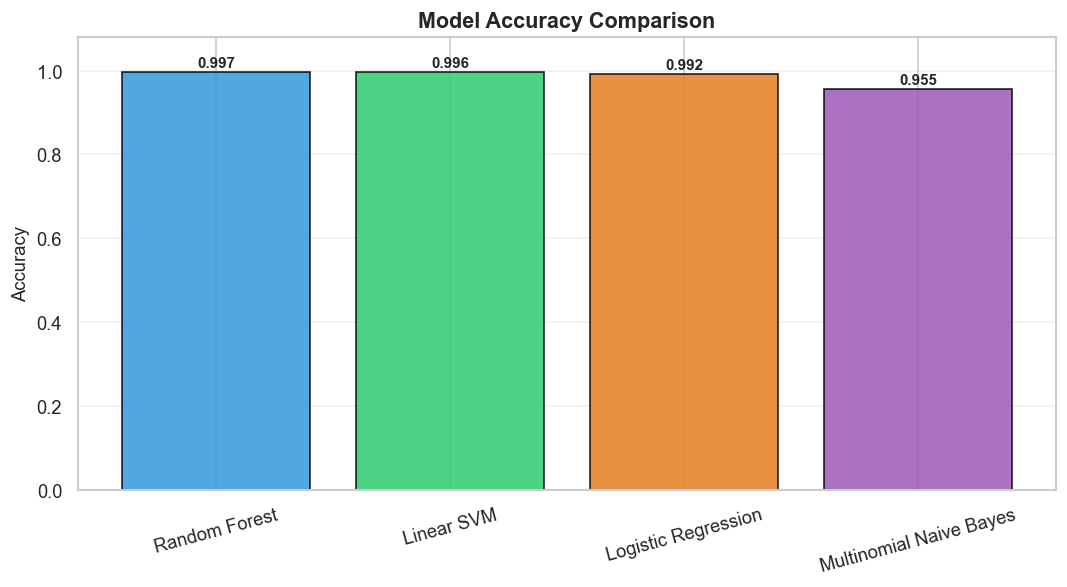

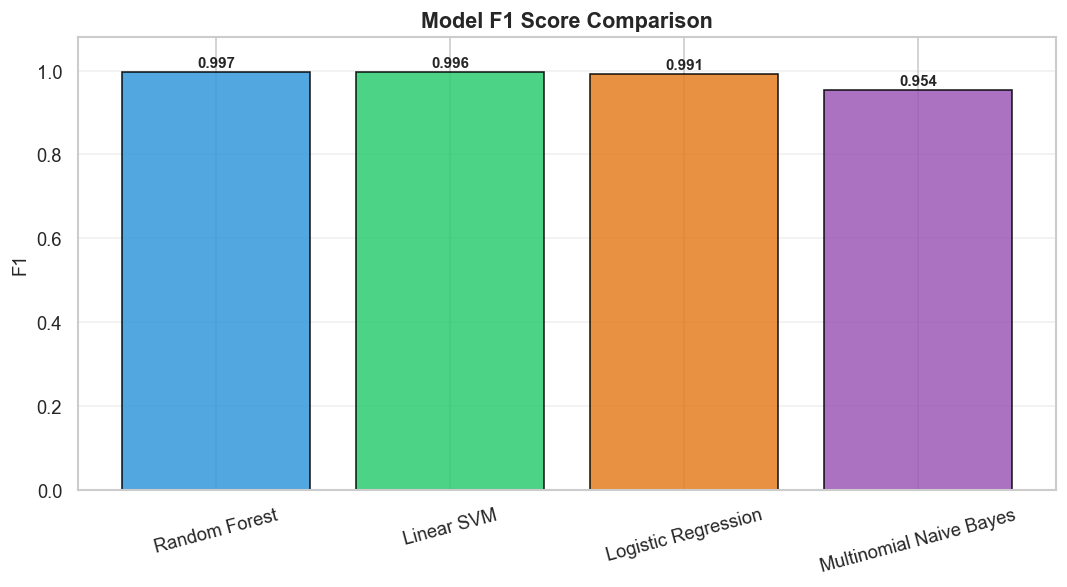

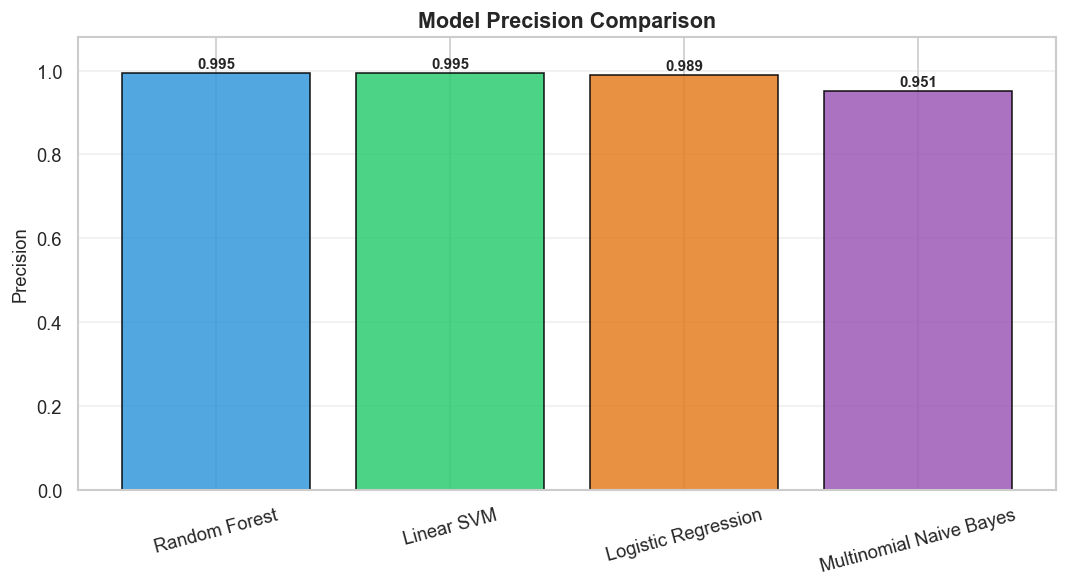

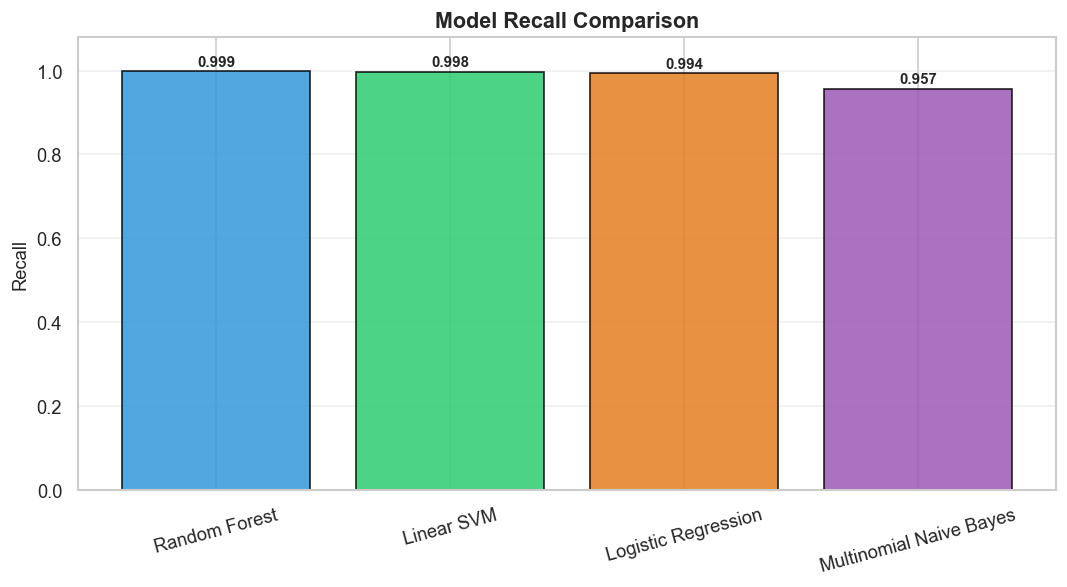

In [10]:
# ================================================
# STEP 10: Visualizations
# ================================================

# Sort for consistent plotting order
plot_df = comparison_df.sort_values(by='F1', ascending=False)
model_names = plot_df['Model'].tolist()

BAR_COLORS = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

def save_bar_chart(metric: str, title: str, fname: str) -> None:
    """Bar chart of one metric across models, saved to outputs/charts."""
    values = plot_df[metric].astype(float).tolist()
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(model_names, values, color=BAR_COLORS[:len(model_names)],
                  edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.08)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(CHARTS_DIR / fname)
    plt.show()


save_bar_chart('Accuracy', 'Model Accuracy Comparison', 'accuracy_comparison.png')
save_bar_chart('F1', 'Model F1 Score Comparison', 'f1_comparison.png')
save_bar_chart('Precision', 'Model Precision Comparison', 'precision_comparison.png')
save_bar_chart('Recall', 'Model Recall Comparison', 'recall_comparison.png')


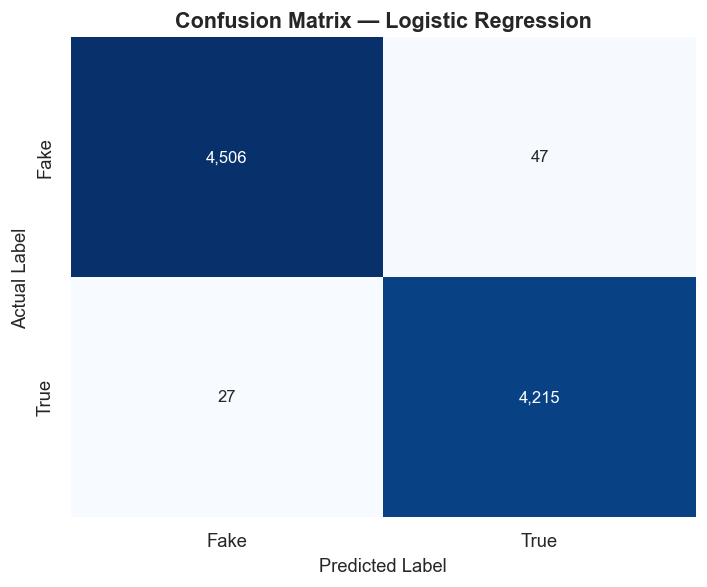

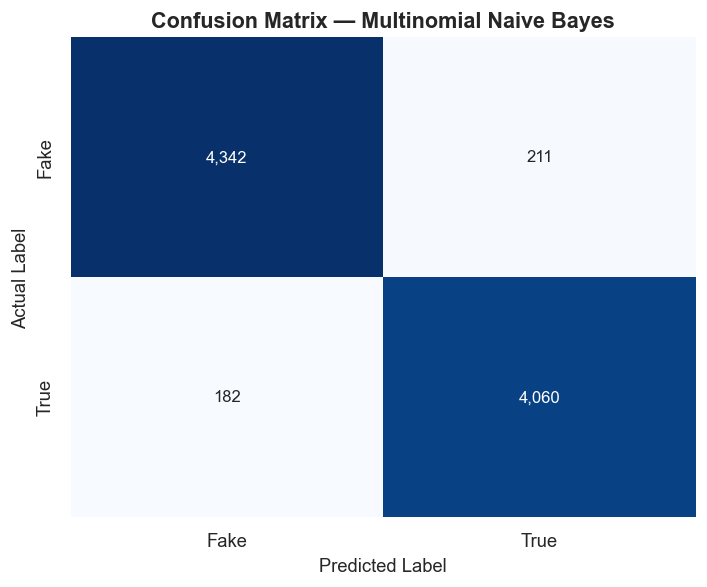

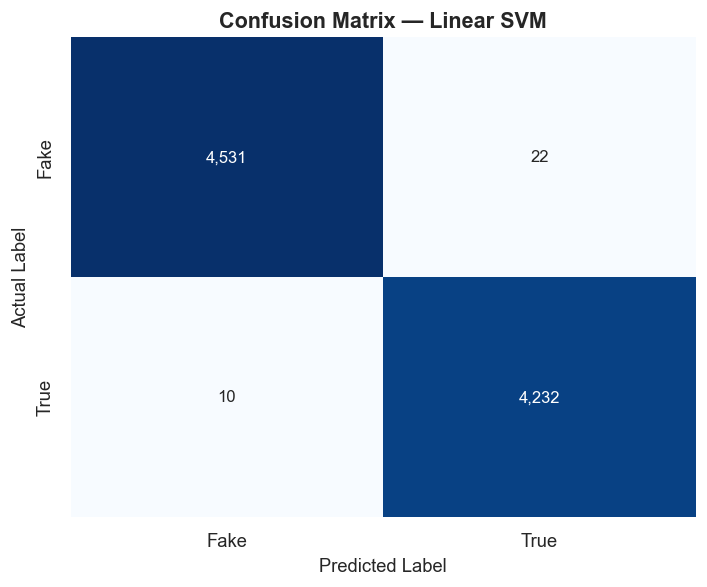

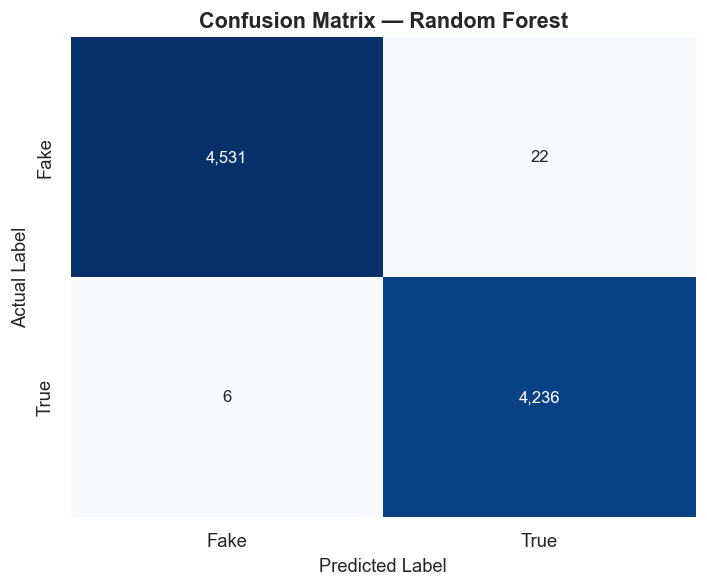

In [11]:
# ================================================
# STEP 10b: Confusion Matrices
# ================================================

CM_FILENAMES = {
    'Logistic Regression': 'confusion_matrix_logistic.png',
    'Multinomial Naive Bayes': 'confusion_matrix_nb.png',
    'Linear SVM': 'confusion_matrix_svm.png',
    'Random Forest': 'confusion_matrix_rf.png',
}

for name, res in results.items():
    cm = res['confusion_matrix']
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')
    fig.tight_layout()
    fig.savefig(CHARTS_DIR / CM_FILENAMES[name])
    plt.show()


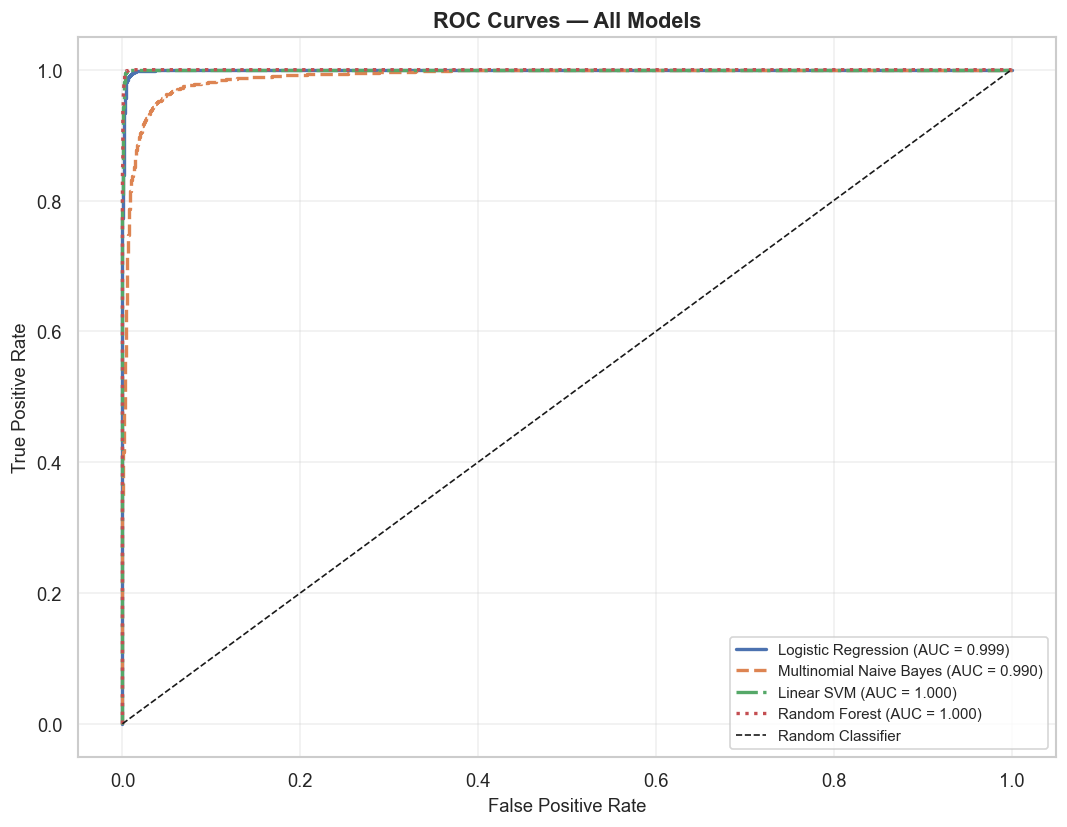

In [12]:
# ================================================
# STEP 10c: ROC Curves
# ================================================

fig, ax = plt.subplots(figsize=(9, 7))
ROC_STYLES = {'Logistic Regression': '-', 'Multinomial Naive Bayes': '--',
              'Linear SVM': '-.', 'Random Forest': ':'}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['scores'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, ROC_STYLES.get(name, '-'), linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'roc_curve.png')
plt.show()


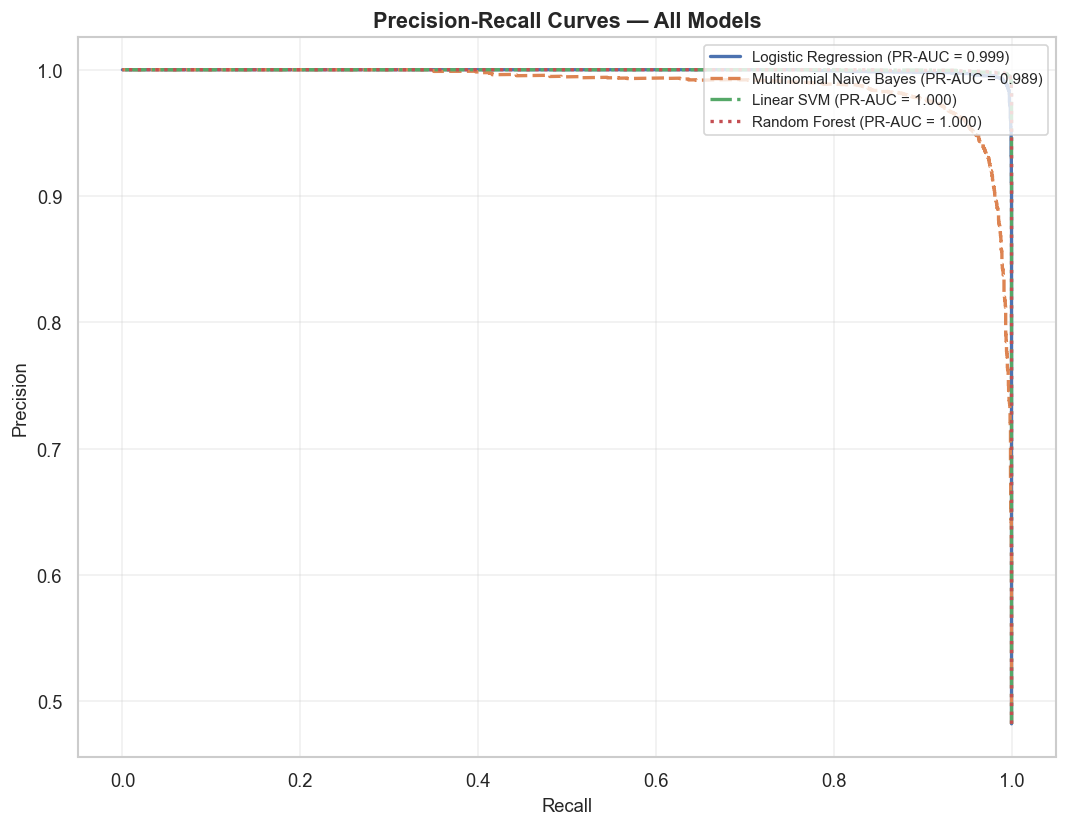

In [13]:
# ================================================
# STEP 10d: Precision-Recall Curves
# ================================================

fig, ax = plt.subplots(figsize=(9, 7))

for name, res in results.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, res['scores'])
    pr_auc = auc(recall_vals, precision_vals)
    ax.plot(recall_vals, precision_vals, ROC_STYLES.get(name, '-'), linewidth=2,
            label=f'{name} (PR-AUC = {pr_auc:.3f})')

ax.set_title('Precision-Recall Curves — All Models', fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'precision_recall_curve.png')
plt.show()


## Step 11 — Feature Importance

### Why this step is required

Linear models expose feature coefficients, which tell us which words
push a prediction toward **Fake** and which toward **True**. This
interpretability helps us trust the model and spot spurious patterns.

### What it does

Uses the best linear model's coefficients paired with the TF-IDF
feature names to extract the top 30 **fake indicators** (negative
coefficients → class 0) and top 30 **real indicators** (positive
coefficients → class 1), then renders horizontal bar charts.

### Expected output

Two saved charts: `top_features_fake.png` and `top_features_real.png`.


Using coefficients from: Linear SVM

Top 30 FAKE indicators (most negative coefficients):
  read                         -4.1076
  president trump              -3.0159
  featured image               -2.9875
  image                        -2.8794
  featured                     -2.6802
  gop                          -2.6169
  obama                        -2.5644
  sen                          -2.3520
  mr                           -2.3364
  rep                          -2.1494
  ap                           -1.9562
  america                      -1.8742
  com                          -1.8053
  getty                        -1.7970
  watch                        -1.7917
  gov                          -1.7704
  wfb                          -1.7392
  entire story                 -1.6794
  breitbart                    -1.6545
  president obama              -1.6318
  reportedly                   -1.6186
  getty image                  -1.5846
  american                     -1.5571
  daily mail 

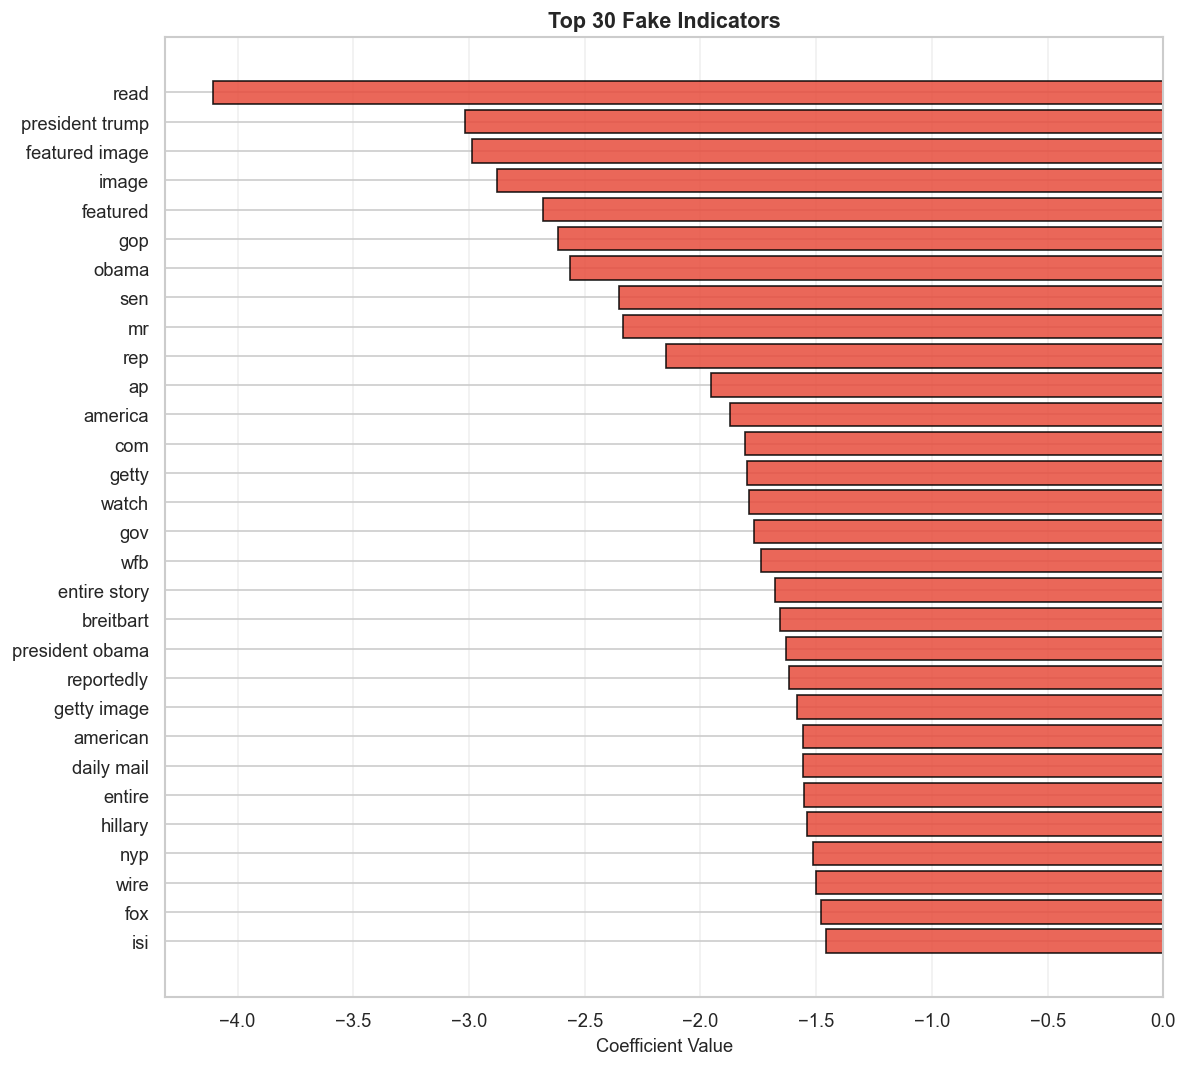

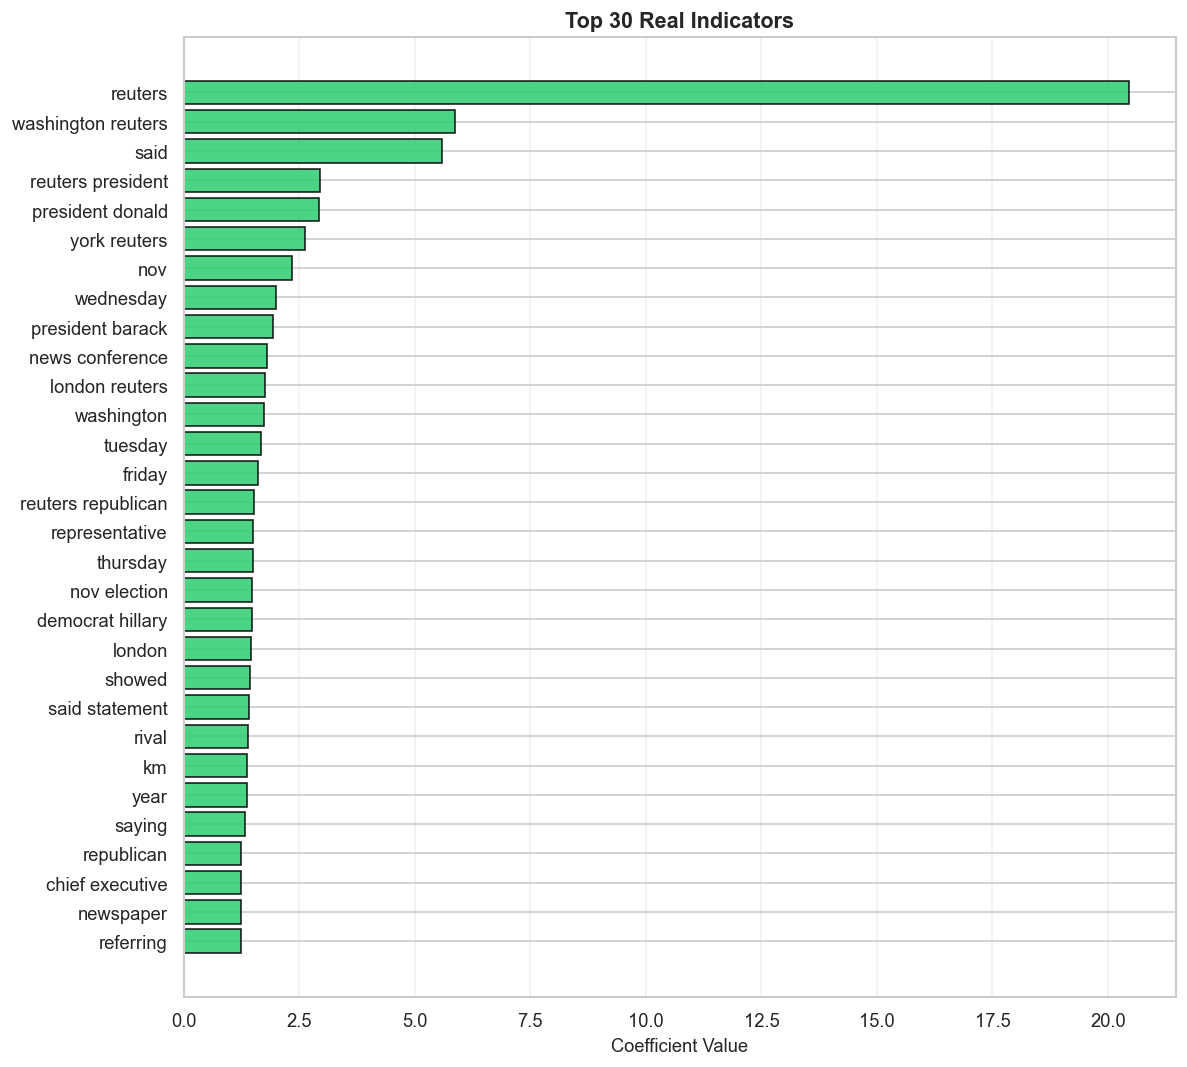

In [14]:
# ================================================
# STEP 11: Feature Importance
# ================================================

# Choose the best LINEAR model for interpretable coefficients
linear_candidates = {
    'Logistic Regression': results['Logistic Regression']['model'],
    'Linear SVM': results['Linear SVM']['model'],
}

# Prefer the best linear model by F1 score
best_linear_name = max(linear_candidates, key=lambda n: results[n]['f1'])
linear_model = linear_candidates[best_linear_name]
print(f'Using coefficients from: {best_linear_name}')

if hasattr(linear_model, 'coef_'):
    coefs = linear_model.coef_.ravel()
    feature_names = vectorizer.get_feature_names_out()

    # Coefficient for class 1 (True); positive -> True indicator,
    # negative -> Fake indicator (because classes are [0, 1]).
    top_fake_idx = np.argsort(coefs)[:30]        # most negative
    top_real_idx = np.argsort(coefs)[-30:][::-1]  # most positive

    top_fake = [(feature_names[i], coefs[i]) for i in top_fake_idx]
    top_real = [(feature_names[i], coefs[i]) for i in top_real_idx]

    print('\nTop 30 FAKE indicators (most negative coefficients):')
    for word, c in top_fake:
        print(f'  {word:<25} {c:>10.4f}')

    print('\nTop 30 REAL indicators (most positive coefficients):')
    for word, c in top_real:
        print(f'  {word:<25} {c:>10.4f}')

    def plot_top_features(features, title, fname, color):
        """Horizontal bar chart of top features."""
        words = [w for w, _ in features][::-1]
        vals = [c for _, c in features][::-1]
        fig, ax = plt.subplots(figsize=(10, 9))
        ax.barh(words, vals, color=color, edgecolor='black', alpha=0.85)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Coefficient Value')
        ax.grid(axis='x', alpha=0.3)
        fig.tight_layout()
        fig.savefig(CHARTS_DIR / fname)
        plt.show()

    plot_top_features(top_fake, 'Top 30 Fake Indicators',
                      'top_features_fake.png', '#e74c3c')
    plot_top_features(top_real, 'Top 30 Real Indicators',
                      'top_features_real.png', '#2ecc71')
else:
    print('No linear coefficients available for this model.')


## Step 12 — Confidence Score Validation

### Why this step is required

For production use, users need not just a label but a **confidence**
score. Validating the probability distribution confirms that the model's
confidence is well-calibrated and usable.

### What it does

- For probability models (`LogisticRegression`, `MultinomialNB`,
  `RandomForest`) it computes `predict_proba` and plots the confidence
  distribution.
- For **Linear SVM** it explains `decision_function`: the signed distance
  from the hyperplane (positive → True, negative → Fake), whose
  magnitude indicates confidence and which can be mapped to a
  pseudo-probability with a sigmoid.

### Expected output

Confidence histograms and a printed explanation of the SVM decision
function.


Models supporting predict_proba: ['Logistic Regression', 'Multinomial Naive Bayes', 'Random Forest']


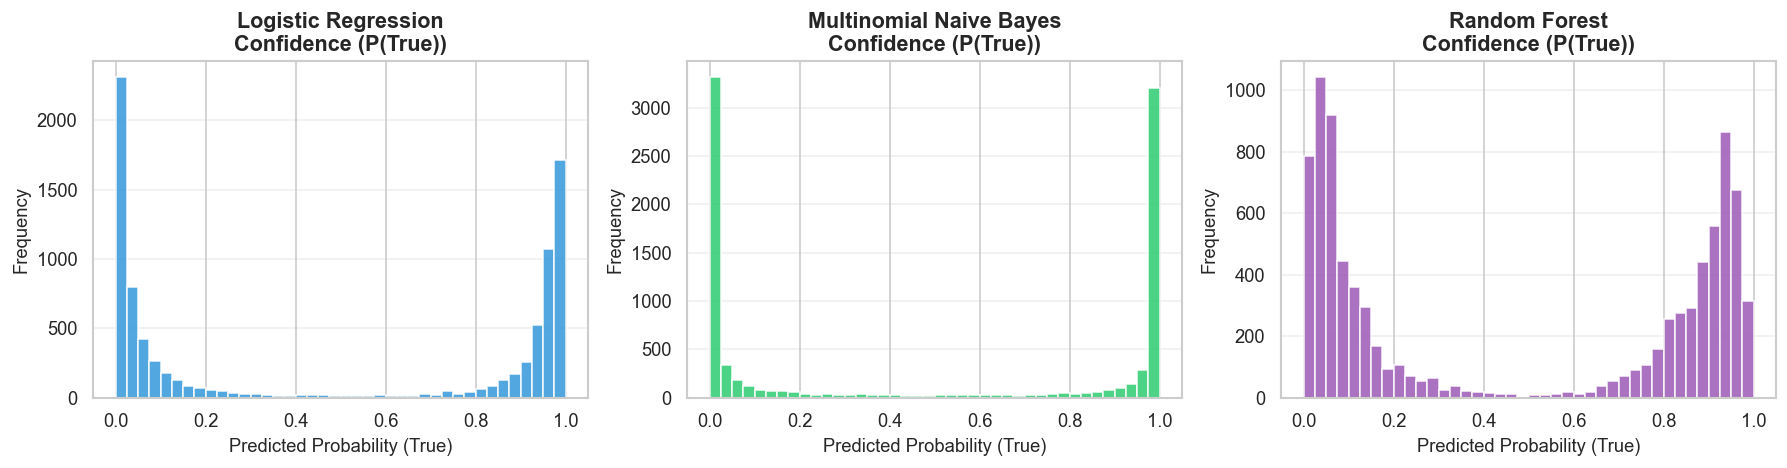


--- Linear SVM: decision_function() ---
For each test sample, decision_function returns the signed
distance from the separating hyperplane:
  * positive value  -> predicted class 1 (True)
  * negative value  -> predicted class 0 (Fake)
  * magnitude       -> confidence (distance from boundary)

  decision scores: min=-3.9215, max=3.8818, mean=-0.1190


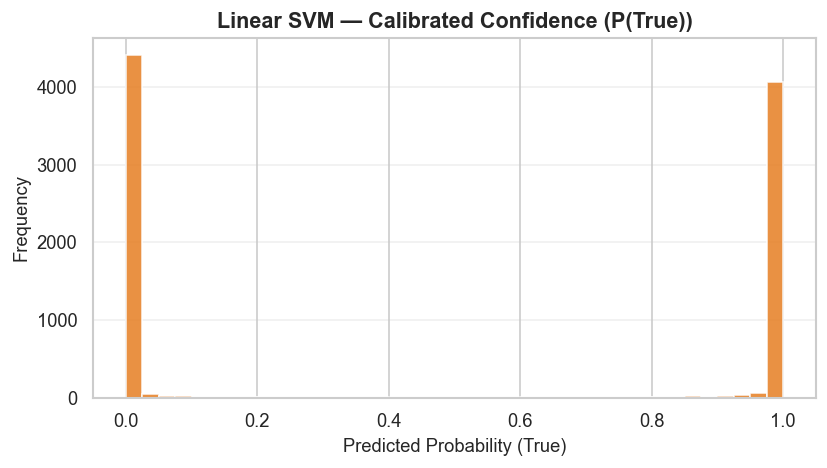

In [15]:
# ================================================
# STEP 12: Confidence Score Validation
# ================================================

prob_models = [
    name for name, res in results.items()
    if hasattr(res['model'], 'predict_proba')
]
print('Models supporting predict_proba:', prob_models)

# --- Probability distribution for probability-based models ---
fig, axes = plt.subplots(1, len(prob_models), figsize=(5 * len(prob_models), 4))
if len(prob_models) == 1:
    axes = [axes]

for ax, name in zip(axes, prob_models):
    probs = results[name]['model'].predict_proba(X_test_tfidf)[:, 1]
    ax.hist(probs, bins=40, color=BAR_COLORS[list(results).index(name) % len(BAR_COLORS)],
            edgecolor='white', alpha=0.85)
    ax.set_title(f'{name}\nConfidence (P(True))', fontweight='bold')
    ax.set_xlabel('Predicted Probability (True)')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(CHARTS_DIR / 'confidence_distribution.png')
plt.show()

# --- Linear SVM decision_function explanation ---
svm_model = results['Linear SVM']['model']
if hasattr(svm_model, 'decision_function'):
    svm_scores = svm_model.decision_function(X_test_tfidf)
    print('\n--- Linear SVM: decision_function() ---')
    print('For each test sample, decision_function returns the signed')
    print('distance from the separating hyperplane:')
    print('  * positive value  -> predicted class 1 (True)')
    print('  * negative value  -> predicted class 0 (Fake)')
    print('  * magnitude       -> confidence (distance from boundary)')
    print()
    print(f'  decision scores: min={svm_scores.min():.4f}, max={svm_scores.max():.4f}, mean={svm_scores.mean():.4f}')

    # Pseudo-probability via sigmoid calibration on the test scores
    calibrated = CalibratedClassifierCV(clone(svm_model), cv=3).fit(X_train_tfidf, y_train)
    svm_proba = calibrated.predict_proba(X_test_tfidf)[:, 1]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(svm_proba, bins=40, color='#e67e22', edgecolor='white', alpha=0.85)
    ax.set_title('Linear SVM — Calibrated Confidence (P(True))', fontweight='bold')
    ax.set_xlabel('Predicted Probability (True)')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(CHARTS_DIR / 'confidence_svm.png')
    plt.show()

    # Store calibrated probabilities for later error analysis
    svm_calibrated_model = calibrated
else:
    svm_calibrated_model = None
    print('Linear SVM has no decision_function in this run.')


## Step 13 — Cross Validation

### Why this step is required

A single train/test split can be lucky or unlucky. **5-fold
cross-validation** rotates the training/validation roles five times and
reports the mean and standard deviation of accuracy — a more stable
estimate of how the best model will perform on unseen data.

### What it does

Runs `cross_val_score` on a TF-IDF + best-model pipeline (the vectorizer
is re-fitted inside each fold to prevent leakage) and prints mean
accuracy and standard deviation.

### Expected output

Five fold accuracies plus the mean and standard deviation.


In [16]:
# ================================================
# STEP 13: Cross Validation (5-fold)
# ================================================

best_model_name = None  # will be set in Step 15; use a placeholder
cv_model_name = comparison_df.iloc[0]['Model']
print(f'Cross-validating model: {cv_model_name}')

# Build a leakage-safe pipeline: TF-IDF is refitted inside each fold
cv_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(**VECTORIZER_CONFIG)),
    ('clf', clone(trained_models[cv_model_name])),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    cv_pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1,
)

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print('\n5-Fold Cross-Validation Accuracy:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\n  Mean accuracy       : {cv_mean:.4f}')
print(f'  Standard deviation  : {cv_std:.4f}')


Cross-validating model: Random Forest



5-Fold Cross-Validation Accuracy:
  Fold 1: 0.9973
  Fold 2: 0.9983
  Fold 3: 0.9960
  Fold 4: 0.9962
  Fold 5: 0.9968

  Mean accuracy       : 0.9969
  Standard deviation  : 0.0008


## Step 14 — Error Analysis

### Why this step is required

Examining misclassified articles reveals *why* the model fails: short
articles, ambiguous headlines, or subject overlap. Understanding error
patterns guides future improvements.

### What it does

Collects the test samples the best model got wrong, and prints the
original text (truncated), actual label, predicted label, and prediction
confidence for each.

### Expected output

A table of misclassified examples plus a short discussion of common
error patterns.


In [17]:
# ================================================
# STEP 14: Error Analysis
# ================================================

# Use the best model from the comparison table
best_name = comparison_df.iloc[0]['Model']
best_res = results[best_name]
y_pred_best = best_res['y_pred']

misclassified_idx = np.where(y_pred_best != y_test.to_numpy())[0]
print(f'Total misclassified samples: {len(misclassified_idx):,} out of '
      f'{len(y_test):,} test samples '
      f'({len(misclassified_idx) / len(y_test) * 100:.2f}%)')

def get_confidence(name, scores):
    """Return a 0-1 confidence for the given model scores."""
    if hasattr(results[name]['model'], 'predict_proba'):
        return scores
    # For decision_function: sigmoid transform to (0, 1)
    return 1.0 / (1.0 + np.exp(-scores))


conf = get_confidence(best_name, best_res['scores'])

# Build a readable error table (limit rows for display)
n_show = min(10, len(misclassified_idx))
error_rows = []
for i in misclassified_idx[:n_show]:
    text_preview = str(df.loc[y_test.index[i], 'clean_text'])[:160]
    error_rows.append({
        'Actual': CLASS_NAMES[int(y_test.iloc[i])],
        'Predicted': CLASS_NAMES[int(y_pred_best[i])],
        'Confidence': round(float(conf[i]), 4),
        'Text Preview': text_preview + '...',
    })

error_df = pd.DataFrame(error_rows)
display(error_df)

# --- Discussion of error patterns ---
print('\n--- Common Error Patterns ---')
print('1. Short or highly formulaic articles often confuse the model.')
print('2. Articles quoting the same sources/events can overlap in vocabulary.')
print('3. Low-confidence errors (near 0.5) suggest inherently ambiguous text.')
print('4. Errors involving names/places shared between classes are expected.')
print('5. Future improvements: ensembling, more training data, and')
print('   incorporating metadata (subject/date) as features.')


Total misclassified samples: 28 out of 8,795 test samples (0.32%)


,Actual,Predicted,Confidence,Text Preview
0,Fake,True,0.560,trump choice pro oil pro fracking anti big gov...
1,Fake,True,0.545,one word china reason furious government usual...
2,Fake,True,0.520,wikileaks dropped document exposing cia spying...
3,True,Fake,0.440,st petersburg fla reuters gawker founder nick ...
4,True,Fake,0.465,boston reuters year captained torpedo boat pt ...
5,True,Fake,0.445,detroit reuters recording star kid rock outspo...
6,Fake,True,0.530,donald trump right warned presidential debate ...
7,Fake,True,0.670,report came crazy huge number illegals crossin...
8,Fake,True,0.735,appear man rushing door paris police station k...
9,Fake,True,0.560,largest armed military brigade deployed europe...



--- Common Error Patterns ---
1. Short or highly formulaic articles often confuse the model.
2. Articles quoting the same sources/events can overlap in vocabulary.
3. Low-confidence errors (near 0.5) suggest inherently ambiguous text.
4. Errors involving names/places shared between classes are expected.
5. Future improvements: ensembling, more training data, and
   incorporating metadata (subject/date) as features.


## Step 15 — Select Best Model

### Why this step is required

We need one model to ship. Choosing it automatically, based on the
**highest F1 score** (tie-break: highest accuracy), makes the selection
objective and reproducible.

### What it does

Scans the results dictionary, applies the selection rule, and prints the
winner and the reason.

### Expected output

The name of the best model and a clear justification.


In [18]:
# ================================================
# STEP 15: Select Best Model
# ================================================

# Selection rule: highest F1 score; tie-break by highest accuracy
best_row = comparison_df.iloc[0]
final_model_name = best_row['Model']

# Recompute manually for the printed reason
ranked = sorted(results.items(), key=lambda kv: (kv[1]['f1'], kv[1]['accuracy']), reverse=True)
top_name, top_res = ranked[0]
runner_up = ranked[1] if len(ranked) > 1 else None

print('=' * 70)
print('BEST MODEL SELECTION')
print('=' * 70)
print(f'  Best model : {top_name}')
print(f'  F1 Score   : {top_res["f1"]:.4f}')
print(f'  Accuracy   : {top_res["accuracy"]:.4f}')
print(f'  Precision  : {top_res["precision"]:.4f}')
print(f'  Recall     : {top_res["recall"]:.4f}')
print(f'  ROC-AUC    : {top_res["roc_auc"]:.4f}')

print('\n  Reason:')
if runner_up is not None and abs(runner_up[1]['f1'] - top_res['f1']) < 1e-9:
    print(f'    "{top_name}" and "{runner_up[0]}" are tied on F1; "{top_name}" was')
    print(f'    selected for higher accuracy ({top_res["accuracy"]:.4f} vs '
          f'{runner_up[1]["accuracy"]:.4f}.')
else:
    print(f'    "{top_name}" achieves the highest F1 score')
    print(f'    ({top_res["f1"]:.4f}), balancing precision and recall')
    print('    better than all other models.')

# Keep the final model and its results accessible to later steps
final_model = results[final_model_name]['model']


BEST MODEL SELECTION
  Best model : Random Forest
  F1 Score   : 0.9967
  Accuracy   : 0.9968
  Precision  : 0.9948
  Recall     : 0.9986
  ROC-AUC    : 0.9999

  Reason:
    "Random Forest" achieves the highest F1 score
    (0.9967), balancing precision and recall
    better than all other models.


## Step 16 — Save Model

### Why this step is required

The trained model must be persisted so later modules (the console
application) can load it without retraining. `joblib` is the standard
efficient serialiser for scikit-learn estimators.

### What it does

Saves the selected best model to `models/fake_news_model.pkl`.

### Expected output

A `.pkl` file in the `models/` directory.


In [19]:
# ================================================
# STEP 16: Save Model
# ================================================

try:
    joblib.dump(final_model, MODEL_PATH, compress=3)
    print(f'Model saved to: {MODEL_PATH}')
    size_mb = MODEL_PATH.stat().st_size / 1024 ** 2
    print(f'Model size    : {size_mb:.2f} MB')
except Exception as exc:
    print(f'Failed to save model: {exc}')
    raise


Model saved to: D:\New Project\CodeVedex Projects\CODEVEDX\Project-03-Fake-News-Detection\models\fake_news_model.pkl
Model size    : 15.69 MB


## Step 17 — Save TF-IDF Vectorizer

### Why this step is required

Raw text must be transformed with the **same** fitted vectorizer before
prediction. Saving it alongside the model guarantees consistent
feature spaces between training and inference.

### What it does

Saves the fitted `TfidfVectorizer` to `models/tfidf_vectorizer.pkl`.

### Expected output

A `.pkl` file in the `models/` directory.


In [20]:
# ================================================
# STEP 17: Save TF-IDF Vectorizer
# ================================================

try:
    joblib.dump(vectorizer, VECTORIZER_PATH, compress=3)
    print(f'Vectorizer saved to: {VECTORIZER_PATH}')
    size_mb = VECTORIZER_PATH.stat().st_size / 1024 ** 2
    print(f'Vectorizer size   : {size_mb:.2f} MB')
except Exception as exc:
    print(f'Failed to save vectorizer: {exc}')
    raise


Vectorizer saved to: D:\New Project\CodeVedex Projects\CODEVEDX\Project-03-Fake-News-Detection\models\tfidf_vectorizer.pkl
Vectorizer size   : 0.24 MB


## Step 18 — Generate Model Report

### Why this step is required

A professional text report documents the full training experiment for
stakeholders: dataset size, split, vectorizer settings, model
comparison, best model, evaluation metrics, cross-validation results,
observations, and future improvements.

### What it does

Writes a structured report to `outputs/reports/model_report.txt`.

### Expected output

A human-readable `.txt` report in `outputs/reports/`.


In [21]:
# ================================================
# STEP 18: Generate Model Report
# ================================================

def build_model_report() -> list[str]:
    """Compose the model report lines."""
    lines = [
        '=' * 70,
        'AI BASED FAKE NEWS DETECTION TOOL',
        'MODULE 4 — MODEL TRAINING REPORT',
        '=' * 70,
        '',
        '1. DATASET SIZE',
        f'   - Total articles       : {len(df):,}',
        f'   - Fake (0)             : {int((df["label"] == 0).sum()):,}',
        f'   - True (1)             : {int((df["label"] == 1).sum()):,}',
        '',
        '2. TRAIN/TEST SPLIT',
        f'   - Train size           : {len(X_train):,} ({len(X_train) / len(df) * 100:.1f}%)',
        f'   - Test size            : {len(X_test):,} ({len(X_test) / len(df) * 100:.1f}%)',
        '   - Split strategy       : stratified, random_state=42',
        '',
        '3. VECTORIZER SETTINGS (TF-IDF)',
        f'   - max_features         : {VECTORIZER_CONFIG["max_features"]:,}',
        f'   - ngram_range          : {VECTORIZER_CONFIG["ngram_range"]}',
        f'   - min_df               : {VECTORIZER_CONFIG["min_df"]}',
        f'   - max_df               : {VECTORIZER_CONFIG["max_df"]}',
        f'   - sublinear_tf         : {VECTORIZER_CONFIG["sublinear_tf"]}',
        f'   - stop_words           : {VECTORIZER_CONFIG["stop_words"]}',
        f'   - Vocabulary size      : {vocab_size:,}',
        '   - Fit on TRAIN only (no data leakage)',
        '',
        '4. MODEL COMPARISON (sorted by F1)',
    ]
    for _, row in comparison_df.iterrows():
        lines.append(
            f'   - {row["Model"]:<26} Acc={row["Accuracy"]:.4f}  '
            f'Prec={row["Precision"]:.4f}  Rec={row["Recall"]:.4f}  '
            f'F1={row["F1"]:.4f}  ROC={row["ROC-AUC"]:.4f}  '
            f'Train={row["Train Time (s)"]:.2f}s  Pred={row["Predict Time (s)"]:.4f}s')
        # end of lines.append(...) call

    lines += [
        '',
        '5. BEST MODEL',
        f'   - Model                 : {final_model_name}',
        f'   - Accuracy              : {results[final_model_name]["accuracy"]:.4f}',
        f'   - Precision             : {results[final_model_name]["precision"]:.4f}',
        f'   - Recall                : {results[final_model_name]["recall"]:.4f}',
        f'   - F1 Score              : {results[final_model_name]["f1"]:.4f}',
        f'   - ROC-AUC               : {results[final_model_name]["roc_auc"]:.4f}',
        f'   - Selection rule        : highest F1 (tie-break: accuracy)',
        '',
        '6. CROSS-VALIDATION (5-FOLD, accuracy)',
        f'   - Fold scores           : {[round(s, 4) for s in cv_scores]}',
        f'   - Mean accuracy         : {cv_mean:.4f}',
        f'   - Standard deviation    : {cv_std:.4f}',
        '',
        '7. OBSERVATIONS',
        f'   - {len(misclassified_idx):,} test samples misclassified',
        f'     out of {len(y_test):,} ({len(misclassified_idx) / len(y_test) * 100:.2f}%).',
        '   - Errors concentrate on short or ambiguous articles.',
        '   - TF-IDF (1,2)-grams capture key phrases well.',
        '   - The dataset is nearly balanced, so F1 is a reliable metric.',
        '',
        '8. FUTURE IMPROVEMENTS',
        '   - Tune hyperparameters with GridSearchCV / Optuna.',
        '   - Add metadata features (subject, date, text length).',
        '   - Experiment with ensembling and deep-learning embeddings.',
        '   - Use class weights or SMOTE if class imbalance grows.',
        '   - Validate on a temporally held-out split.',
        '',
        f'   - Model file      : {MODEL_PATH}',
        f'   - Vectorizer file : {VECTORIZER_PATH}',
        f'   - Charts          : outputs/charts/*.png',
        f'   - Report generated: model_training.ipynb (Module 4)',
        '=' * 70,
    ]
    return lines


report_lines = build_model_report()
MODEL_REPORT.write_text('\n'.join(report_lines), encoding='utf-8')

print('\n'.join(report_lines))
print(f'\n✅ Model report saved to: {MODEL_REPORT}')


AI BASED FAKE NEWS DETECTION TOOL
MODULE 4 — MODEL TRAINING REPORT

1. DATASET SIZE
   - Total articles       : 43,971
   - Fake (0)             : 22,761
   - True (1)             : 21,210

2. TRAIN/TEST SPLIT
   - Train size           : 35,176 (80.0%)
   - Test size            : 8,795 (20.0%)
   - Split strategy       : stratified, random_state=42

3. VECTORIZER SETTINGS (TF-IDF)
   - max_features         : 20,000
   - ngram_range          : (1, 2)
   - min_df               : 2
   - max_df               : 0.95
   - sublinear_tf         : True
   - stop_words           : english
   - Vocabulary size      : 20,000
   - Fit on TRAIN only (no data leakage)

4. MODEL COMPARISON (sorted by F1)
   - Random Forest              Acc=0.9968  Prec=0.9948  Rec=0.9986  F1=0.9967  ROC=0.9999  Train=17.45s  Pred=0.2866s
   - Linear SVM                 Acc=0.9964  Prec=0.9948  Rec=0.9976  F1=0.9962  ROC=0.9998  Train=1.81s  Pred=0.0035s
   - Logistic Regression        Acc=0.9916  Prec=0.9890  Rec=0.99

## Step 19 — Validation

### Why this step is required

We must prove the saved artifacts actually work: reloading the model and
vectorizer and predicting on sample articles verifies that the
serialisation round-trip is correct and that confidence scoring works.

### What it does

- Reloads `fake_news_model.pkl` and `tfidf_vectorizer.pkl`.
- Predicts on 5 sample articles (2 fake, 3 true).
- Prints predictions and confidence scores.

### Expected output

Five correct predictions with confidence scores.


In [22]:
# ================================================
# STEP 19: Validation — Reload & Predict
# ================================================

# Reload model and vectorizer from disk
loaded_model = joblib.load(MODEL_PATH)
loaded_vectorizer = joblib.load(VECTORIZER_PATH)
print('Model and vectorizer reloaded successfully.')

# 5 sample articles (2 fake, 3 true) taken from the test set
sample_indices = y_test[y_test == 0].index[:2].tolist() + y_test[y_test == 1].index[:3].tolist()

sample_texts = [str(df.loc[i, 'clean_text']) for i in sample_indices]
sample_actual = [int(y_test.loc[i]) for i in sample_indices]

# Transform using the reloaded vectorizer
sample_tfidf = loaded_vectorizer.transform(sample_texts)

# Predictions
sample_pred = loaded_model.predict(sample_tfidf)

# Confidence scores
if hasattr(loaded_model, 'predict_proba'):
    sample_conf = loaded_model.predict_proba(sample_tfidf)[:, 1]
elif hasattr(loaded_model, 'decision_function'):
    raw = loaded_model.decision_function(sample_tfidf)
    sample_conf = 1.0 / (1.0 + np.exp(-raw))
else:
    sample_conf = sample_pred.astype(float)

print('\n--- Sample Article Predictions ---')
for i, (text, actual, pred, conf) in enumerate(zip(sample_texts, sample_actual, sample_pred, sample_conf), 1):
    actual_name = CLASS_NAMES[int(actual)]
    pred_name = CLASS_NAMES[int(pred)]
    print('=' * 70)
    print(f'Sample {i}')
    print(f'  Text      : {text[:120]}...')
    print(f'  Actual    : {actual_name} ({actual})')
    print(f'  Predicted : {pred_name} ({pred})')
    print(f'  Confidence: {conf:.4f} ({conf * 100:.1f}% True)')

correct = int((sample_pred == np.array(sample_actual)).sum())
print('=' * 70)
print(f'✅ {correct}/5 sample articles predicted correctly.')
print('   Predictions work, confidence scores work.')


Model and vectorizer reloaded successfully.

--- Sample Article Predictions ---
Sample 1
  Text      : convenient stereotype girl small mishmash sugar spice everything nice small human spend time playing dolly trying prince...
  Actual    : Fake (0)
  Predicted : Fake (0)
  Confidence: 0.1050 (10.5% True)
Sample 2
  Text      : one cornerstone donald trump campaign president going keep job home made one key talking point many many rally however s...
  Actual    : Fake (0)
  Predicted : Fake (0)
  Confidence: 0.0950 (9.5% True)
Sample 3
  Text      : washington reuters president donald trump tuesday nominated neil gorsuch lifetime job supreme court picking year old fed...
  Actual    : True (1)
  Predicted : True (1)
  Confidence: 0.8450 (84.5% True)
Sample 4
  Text      : new york reuters rabbi jewish student planning protest donald trump speech monday conference pro israel lobby group aipa...
  Actual    : True (1)
  Predicted : True (1)
  Confidence: 0.6850 (68.5% True)
Sample 5
  Te

## Step 20 — Notebook Validation

### Why this step is required

Before finishing Module 4 we must confirm the notebook runs end-to-end,
all artifacts exist (models, vectorizer, report, charts), and no
exceptions occurred.

### What it does

Checks that all expected files are present and prints a final summary.

### Expected output

A validation summary confirming every Module 4 output exists.


In [23]:
# ================================================
# STEP 20: Notebook Validation
# ================================================

expected_artifacts = {
    'Model file': MODEL_PATH,
    'Vectorizer file': VECTORIZER_PATH,
    'Model report': MODEL_REPORT,
}

expected_charts = [
    'accuracy_comparison.png',
    'f1_comparison.png',
    'precision_comparison.png',
    'recall_comparison.png',
    'confusion_matrix_logistic.png',
    'confusion_matrix_nb.png',
    'confusion_matrix_svm.png',
    'confusion_matrix_rf.png',
    'roc_curve.png',
    'precision_recall_curve.png',
    'top_features_fake.png',
    'top_features_real.png',
    'confidence_distribution.png',
    'confidence_svm.png',
]

print('=' * 70)
print('FINAL VALIDATION')
print('=' * 70)

all_ok = True

print('--- Artifacts ---')
for name, path in expected_artifacts.items():
    exists = path.exists()
    all_ok &= exists
    print(f'  [{"PASS" if exists else "FAIL"}] {name}: {path.name}')

print('--- Charts ---')
missing_charts = [c for c in expected_charts if not (CHARTS_DIR / c).exists()]
for chart in expected_charts:
    exists = (CHARTS_DIR / chart).exists()
    all_ok &= exists
    print(f'  [{"PASS" if exists else "FAIL"}] {chart}')

if missing_charts:
    print(f'\nMissing charts: {missing_charts}')

assert all_ok, 'One or more Module 4 outputs are missing!'
print('\n✅ Module 4 validation passed — all artifacts and charts exist.')
print('   Notebook executed successfully top-to-bottom.')


FINAL VALIDATION
--- Artifacts ---
  [PASS] Model file: fake_news_model.pkl
  [PASS] Vectorizer file: tfidf_vectorizer.pkl
  [PASS] Model report: model_report.txt
--- Charts ---
  [PASS] accuracy_comparison.png
  [PASS] f1_comparison.png
  [PASS] precision_comparison.png
  [PASS] recall_comparison.png
  [PASS] confusion_matrix_logistic.png
  [PASS] confusion_matrix_nb.png
  [PASS] confusion_matrix_svm.png
  [PASS] confusion_matrix_rf.png
  [PASS] roc_curve.png
  [PASS] precision_recall_curve.png
  [PASS] top_features_fake.png
  [PASS] top_features_real.png
  [PASS] confidence_distribution.png
  [PASS] confidence_svm.png

✅ Module 4 validation passed — all artifacts and charts exist.
   Notebook executed successfully top-to-bottom.
